In [20]:
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
from scipy.sparse import csc_matrix

raw_dir = Path("../data/raw")

In [21]:
2+2

4

In [22]:
spike_path = raw_dir / "YFF" / "arithmetic" / "spikes.mat"

with h5py.File(spike_path, "r") as f:
    spikes = f["spikes"]

    data = spikes["data"][:]
    indices = spikes["ir"][:]
    indptr = spikes["jc"][:]

    n_neurons = int(spikes.attrs["MATLAB_sparse"])
    n_timepoints = len(indptr) - 1

    spike_matrix = csc_matrix(
        (data, indices, indptr),
        shape=(n_neurons, n_timepoints)
    )

print("Spike matrix shape:", spike_matrix.shape)
print("Number of spikes:", spike_matrix.nnz)

Spike matrix shape: (54, 708276)
Number of spikes: 501537


In [23]:
spike_matrix

<Compressed Sparse Column sparse matrix of dtype 'uint8'
	with 501537 stored elements and shape (54, 708276)>

In [24]:
behav_path = raw_dir / "YFF" / "arithmetic" / "photoBehavEvents.csv"

yff = pd.read_csv(behav_path)

print("Behavior shape:", yff.shape)

yff.head()

Behavior shape: (100, 22)


,trial,tCue1,tCue2,tCue3,presentationEnd,tPress1,tPress2,tPress3,keyPress1,keyPress2,...,timeFeedback,cue1,cue2,operation,operationFirst,correctAnsw,givenAnsw,correct,correctFb,toExclude
0,1,5338.733333,6089.466667,6840.200000,7607.600000,13830.233333,14030.500000,NaN,1,1.0,...,15398.433333,5,16,-,1,-11,11,0,1,0
1,2,15882.233333,16632.933333,17383.666667,18167.733333,20453.266667,NaN,NaN,3,NaN,...,21938.033333,2,1,+,0,3,3,1,1,0
2,3,22438.533333,23189.233333,23939.966667,24690.666667,26192.133333,NaN,NaN,7,NaN,...,27576.766667,6,1,+,1,7,7,1,1,0
3,4,28077.300000,28828.000000,29578.700000,30329.433333,34967.200000,35250.833333,NaN,2,1.0,...,36635.466667,0,16,+,0,16,21,0,1,0
4,5,37136.000000,37886.700000,38637.400000,39388.133333,40872.900000,41256.600000,NaN,1,6.0,...,42607.900000,10,6,+,0,16,16,1,1,0


In [25]:
def align_arithmetic_events(df, subject):
    df = df.copy()

    df["operand1_time"] = np.nan
    df["operation_time"] = np.nan
    df["operand2_time"] = np.nan

    # Special protocol
    if subject in ["YFR", "YFS"]:
        df["operand1_time"] = df["tCue1"]
        df["operation_time"] = df["tCue2"]
        df["operand2_time"] = df["tCue3"]

    else:
        # Operand1 -> Operand2 -> Operation
        mask0 = df["operationFirst"] == 0

        df.loc[mask0, "operand1_time"] = df.loc[mask0, "tCue1"]
        df.loc[mask0, "operand2_time"] = df.loc[mask0, "tCue2"]
        df.loc[mask0, "operation_time"] = df.loc[mask0, "tCue3"]

        # Operation -> Operand1 -> Operand2
        mask1 = df["operationFirst"] == 1

        df.loc[mask1, "operation_time"] = df.loc[mask1, "tCue1"]
        df.loc[mask1, "operand1_time"] = df.loc[mask1, "tCue2"]
        df.loc[mask1, "operand2_time"] = df.loc[mask1, "tCue3"]

    return df

In [26]:
yff_aligned = align_arithmetic_events(yff, "YFF")

yff_aligned[
    [
        "trial",
        "cue1",
        "operation",
        "cue2",
        "operand1_time",
        "operation_time",
        "operand2_time"
    ]
].head()

,trial,cue1,operation,cue2,operand1_time,operation_time,operand2_time
0,1,5,-,16,6089.466667,5338.733333,6840.200000
1,2,2,+,1,15882.233333,17383.666667,16632.933333
2,3,6,+,1,23189.233333,22438.533333,23939.966667
3,4,0,+,16,28077.300000,29578.700000,28828.000000
4,5,10,+,6,37136.000000,38637.400000,37886.700000


In [27]:
neuron_id = hpc_neurons[0]

In [28]:
# Select Trial 1
trial = yff_aligned.iloc[0]

# Operand 1 onset
operand1_time = trial["operand1_time"]

# Paper's arithmetic analysis window:
# 50 ms to 950 ms after operand onset
start_ms = int(round(operand1_time + 50))
end_ms   = int(round(operand1_time + 950))

# Start with neuron 0
neuron_id = hpc_neurons[0]

# Extract this neuron's spike train during the window
spikes_window = spike_matrix[
    neuron_id,
    start_ms:end_ms
]

print("Trial:", int(trial["trial"]))
print("Operand 1:", trial["cue1"])
print("Operand 1 onset:", operand1_time, "ms")

print("\nWindow start:", start_ms, "ms")
print("Window end:", end_ms, "ms")
print("Window length:", spikes_window.shape[1], "ms")

print("\nNeuron:", neuron_id)
print("Number of spikes:", spikes_window.sum())

Trial: 1
Operand 1: 5
Operand 1 onset: 6089.46666666667 ms

Window start: 6139 ms
Window end: 7039 ms
Window length: 900 ms

Neuron: 9
Number of spikes: 16


In [29]:
spike_positions = spikes_window.nonzero()[1]

# Because our window begins 50 ms after operand onset
relative_spike_times = spike_positions + 50

print("Number of spikes:", len(relative_spike_times))
print("Spike times relative to Operand 1 onset (ms):")
print(relative_spike_times)

Number of spikes: 16
Spike times relative to Operand 1 onset (ms):
[154 311 347 374 401 433 534 548 564 586 662 800 826 828 845 912]


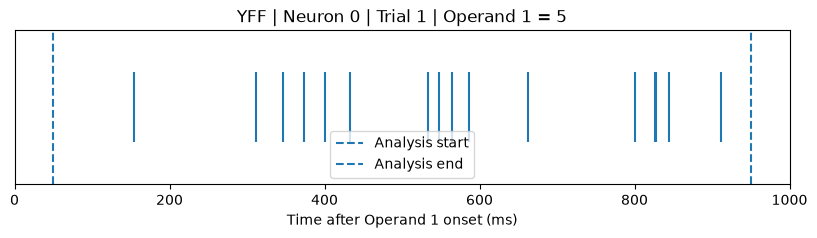

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 2))

plt.eventplot(
    relative_spike_times,
    lineoffsets=1,
    linelengths=0.7
)

plt.axvline(50, linestyle="--", label="Analysis start")
plt.axvline(950, linestyle="--", label="Analysis end")

plt.xlim(0, 1000)
plt.yticks([])

plt.xlabel("Time after Operand 1 onset (ms)")
plt.title("YFF | Neuron 0 | Trial 1 | Operand 1 = 5")

plt.legend()
plt.show()

In [31]:
neuron_id

trial_responses = []

for _, trial in yff_aligned.iterrows():

    operand1 = trial["cue1"]
    onset = trial["operand1_time"]

    start_ms = int(round(onset + 50))
    end_ms   = int(round(onset + 950))

    # Extract this neuron's 900-ms response
    window = spike_matrix[
        neuron_id,
        start_ms:end_ms
    ]

    spike_count = window.sum()

    # 900 ms = 0.9 seconds
    firing_rate = spike_count / 0.9

    trial_responses.append({
        "trial": int(trial["trial"]),
        "operand1": operand1,
        "spike_count": int(spike_count),
        "firing_rate_hz": float(firing_rate),
        "correct": trial["correct"],
        "toExclude": trial["toExclude"]
    })

neuron0_responses = pd.DataFrame(trial_responses)

neuron0_responses.head(10)

,trial,operand1,spike_count,firing_rate_hz,correct,toExclude
0,1,5,16,17.777778,0,0
1,2,2,19,21.111111,1,0
2,3,6,15,16.666667,1,0
3,4,0,11,12.222222,0,0
4,5,10,20,22.222222,1,0
5,6,9,11,12.222222,1,0
6,7,5,17,18.888889,0,0
7,8,8,11,12.222222,1,0
8,9,9,12,13.333333,1,0
9,10,0,8,8.888889,0,0


In [32]:
neuron0_responses

,trial,operand1,spike_count,firing_rate_hz,correct,toExclude
0,1,5,16,17.777778,0,0
1,2,2,19,21.111111,1,0
2,3,6,15,16.666667,1,0
3,4,0,11,12.222222,0,0
4,5,10,20,22.222222,1,0
...,...,...,...,...,...,...
95,96,2,22,24.444444,1,0
96,97,12,13,14.444444,0,0
97,98,7,12,13.333333,1,0
98,99,13,23,25.555556,1,0


In [33]:
print("Last spike-matrix column:", spike_matrix.shape[1] - 1)

print("Last behavioral trial:")
print(yff_aligned.iloc[-1][
    ["trial", "tCue1", "tCue2", "tCue3",
     "presentationEnd", "choiceEnd", "timeFeedback"]
])

last_feedback = yff_aligned["timeFeedback"].max()

print("\nRecording length:", spike_matrix.shape[1], "ms")
print("Last feedback:", last_feedback, "ms")
print("Remaining neural recording:",
      spike_matrix.shape[1] - last_feedback, "ms")

Last spike-matrix column: 708275
Last behavioral trial:
trial                        100
tCue1              701090.433333
tCue2              701824.433333
tCue3              702575.166667
presentationEnd    703325.866667
choiceEnd          707129.533333
timeFeedback            707646.7
Name: 99, dtype: object

Recording length: 708276 ms
Last feedback: 707646.7 ms
Remaining neural recording: 629.3000000000466 ms


In [34]:
def decode_matlab_string(f, ref):
    obj = f[ref]
    values = obj[()].flatten()
    return "".join(chr(int(x)) for x in values)


with h5py.File(spike_path, "r") as f:
    regions = f["regionsVect"]
    refs = regions[0]

    region_labels = [
        decode_matlab_string(f, ref)
        for ref in refs
    ]

print("Number of region labels:", len(region_labels))

for i, region in enumerate(region_labels):
    print(f"Neuron {i}: {region}")

Number of region labels: 54
Neuron 0: acc
Neuron 1: acc
Neuron 2: acc
Neuron 3: acc
Neuron 4: acc
Neuron 5: acc
Neuron 6: acc
Neuron 7: acc
Neuron 8: ent
Neuron 9: hpc
Neuron 10: hpc
Neuron 11: hpc
Neuron 12: hpc
Neuron 13: hpc
Neuron 14: hpc
Neuron 15: hpc
Neuron 16: hpc
Neuron 17: acc
Neuron 18: acc
Neuron 19: acc
Neuron 20: acc
Neuron 21: acc
Neuron 22: acc
Neuron 23: acc
Neuron 24: acc
Neuron 25: acc
Neuron 26: hpc
Neuron 27: hpc
Neuron 28: hpc
Neuron 29: hpc
Neuron 30: hpc
Neuron 31: hpc
Neuron 32: hpc
Neuron 33: hpc
Neuron 34: hpc
Neuron 35: hpc
Neuron 36: hpc
Neuron 37: hpc
Neuron 38: hpc
Neuron 39: hpc
Neuron 40: hpc
Neuron 41: hpc
Neuron 42: hpc
Neuron 43: hpc
Neuron 44: hpc
Neuron 45: hpc
Neuron 46: hpc
Neuron 47: hpc
Neuron 48: hpc
Neuron 49: hpc
Neuron 50: hpc
Neuron 51: hpc
Neuron 52: hpc
Neuron 53: hpc


In [35]:
hpc_neurons = [
    i for i, region in enumerate(region_labels)
    if region == "hpc"
]

print("HPC neuron IDs:")
print(hpc_neurons)

print("Number of HPC neurons:", len(hpc_neurons))

HPC neuron IDs:
[9, 10, 11, 12, 13, 14, 15, 16, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53]
Number of HPC neurons: 36


In [36]:
neuron_id = hpc_neurons[0]

In [37]:
neuron_id

9

In [38]:
neuron_responses = pd.DataFrame(trial_responses)

In [39]:
operand1_tuning = (
    neuron_responses
    .groupby("operand1")
    .agg(
        n_trials=("trial", "count"),
        mean_firing_rate=("firing_rate_hz", "mean"),
        std_firing_rate=("firing_rate_hz", "std")
    )
    .reset_index()
)

operand1_tuning

,operand1,n_trials,mean_firing_rate,std_firing_rate
0,0,10,13.333333,3.008903
1,1,4,17.222222,1.924501
2,2,4,15.277778,9.179284
3,3,5,16.222222,3.975232
4,4,2,13.888889,2.357023
5,5,6,17.592593,1.635511
6,6,10,16.888889,3.696289
7,7,9,16.419753,4.836135
8,8,5,17.555556,5.055250
9,9,10,15.333333,6.170864


In [40]:
operand1_tuning["n_trials"].sum()

np.int64(100)

In [41]:
neuron_responses = pd.DataFrame(trial_responses)

In [42]:
neuron_responses

,trial,operand1,spike_count,firing_rate_hz,correct,toExclude
0,1,5,16,17.777778,0,0
1,2,2,19,21.111111,1,0
2,3,6,15,16.666667,1,0
3,4,0,11,12.222222,0,0
4,5,10,20,22.222222,1,0
...,...,...,...,...,...,...
95,96,2,22,24.444444,1,0
96,97,12,13,14.444444,0,0
97,98,7,12,13.333333,1,0
98,99,13,23,25.555556,1,0


In [43]:
1+1

2

In [44]:
1+1

2

In [46]:
print("Number of HPC neurons:", len(hpc_neurons))

Number of HPC neurons: 36
